In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
import operator
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os

In [47]:
load_dotenv()

True

In [ ]:
model = ChatOpenAI(
    model="openai/gpt-oss-20b", # Structure ouput ka liya ya model specific use kiya ha 
    api_key=os.getenv("Grok_Api_key"),
    base_url="https://api.groq.com/openai/v1"
)

In [49]:
class EvaluationSchema(BaseModel):

    feedback : str = Field(description='Detaild feedback for the eassy')
    score : int = Field(description='Score out of 10 (1 to 10)')

In [50]:
structure_model = model.with_structured_output(EvaluationSchema)

In [51]:
eassy = '''Artificial Intelligence (AI) is transforming the world, and Pakistan is also making significant progress in this field. AI refers to machines and computer systems that can perform tasks requiring human intelligence, such as learning, problem-solving, language understanding, and decision-making. In recent years, AI has become an important part of education, healthcare, agriculture, business, and government services in Pakistan.

The Government of Pakistan has started promoting AI through the National Artificial Intelligence Policy, aiming to encourage research, innovation, and digital transformation. Many universities, including NUST, FAST, COMSATS, and UET, have introduced AI and Data Science programs to prepare students for future technologies.'''

In [52]:
prompt = f'Evaluate the language quality of the following eassy and provide a feedback and assign a score out of 10 \n {eassy}'
structure_model.invoke(prompt)

EvaluationSchema(feedback='The essay demonstrates clear understanding of AI’s relevance to Pakistan, but lacks depth in examples and contains a few grammatical errors such as missing articles and inconsistent verb tense. It would benefit from more detailed discussion of specific AI applications and improved sentence structure to enhance readability. Overall, the language quality is acceptable but could be polished further.', score=7)

In [53]:
class UpscState(TypedDict):

    eassy : str
    language_feedback : str
    analysis_feedback : str
    clarity_feedback : str
    overall_feedback : str
    individual_scores : Annotated[list[int], operator.add]
    avg_score : float

In [54]:
def evaluate_language(state: UpscState):
    prompt = f'Evaluate the language quality of the following eassy and provide a feedback and assign a score out of 10 \n {state["eassy"]}'
    output =structure_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores' : [output.score]}

In [55]:
def evaluate_analysis(state: UpscState):
    prompt = f'Evaluate the depth of analysis of the following eassy and provide a feedback and assign a score out of 10 \n {state["eassy"]}'
    output =structure_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores' : [output.score]}

In [56]:
def evaluate_thought(state: UpscState):
    prompt = f'Evaluate the clarity of thought of the following eassy and provide a feedback and assign a score out of 10 \n {state["eassy"]}'
    output =structure_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores' : [output.score]}

In [57]:
def final_evaluation(state: UpscState):
    prompt = f'Based on the following feedback create a summarize feedback \n language feedback - {state["language_feedback"]} \n depth of feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [58]:
graph = StateGraph(UpscState)

# node
graph.add_node('evaluate_languate', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# edge
graph.add_edge(START, 'evaluate_languate')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_languate', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

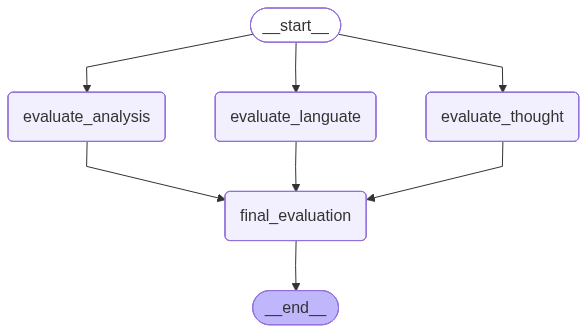

In [59]:
workflow

In [60]:
initial_state = {'eassy': eassy}

workflow.invoke(initial_state)

{'eassy': 'Artificial Intelligence (AI) is transforming the world, and Pakistan is also making significant progress in this field. AI refers to machines and computer systems that can perform tasks requiring human intelligence, such as learning, problem-solving, language understanding, and decision-making. In recent years, AI has become an important part of education, healthcare, agriculture, business, and government services in Pakistan.\n\nThe Government of Pakistan has started promoting AI through the National Artificial Intelligence Policy, aiming to encourage research, innovation, and digital transformation. Many universities, including NUST, FAST, COMSATS, and UET, have introduced AI and Data Science programs to prepare students for future technologies.',
 'language_feedback': 'The essay provides a clear overview of AI’s impact and Pakistan’s initiatives, but contains several grammatical errors and awkward phrasing. Punctuation is inconsistent (missing commas after introductory cl